In [1]:
import bacco
import numpy as np
import h5py
import matplotlib.pyplot as plt

In [2]:
import os
os.chdir("/lscratch/fgmaion/MTNG-resims/src")
import utils

In [3]:
%load_ext autoreload
%autoreload 2

In [4]:
with h5py.File('/cosmos_storage/simulations/MTNG/DM-Gadget4/MTNG-L500-1080-A/snapdir_051/snapshot_051.29.hdf5', 'r') as f:
    print(f['Header'].attrs['NumPart_Total'])

[         0 1259712000]


In [36]:
pos = np.zeros((1259712000, 3), dtype=np.float32)
ids = np.zeros(1259712000, dtype=np.uint64)

istart = np.uint64(0)
total_part = 0
for ifile in range(32):
    ffname = '/cosmos_storage/simulations/MTNG/DM-Gadget4/MTNG-L500-1080-A/snapdir_051/snapshot_051.{:d}.hdf5'.format(ifile)

    with h5py.File(ffname, 'r') as f:
        npts = np.uint64(f['Header'].attrs['NumPart_ThisFile'][1])
        total_part += npts

        if npts > 0:
            pos[istart:istart + npts] = f[u'PartType1']['Coordinates'][()]
            ids[istart:istart + npts] = np.uint64(f[u'PartType1']['ParticleIDs'])
    
    istart += npts


In [44]:
npart = 1080
BoxSize = 500
corr_fac = 0

q = np.zeros(ids.shape + (3,), dtype=np.float32)

q[..., 0] = (ids - 1) // npart**2
q[..., 1] = ((ids - 1) // npart) % npart
q[..., 2] = (ids - 1) % npart

# normalize correctly
q *= (BoxSize / npart)

#q[..., 0] = ( q[...,0] - corr_fac ) % BoxSize # Correction due to differences between MTNG and MTNG-mimic

In [45]:
def distance(d, boxhalf):
    d[np.where(d>boxhalf)] -= boxhalf*2
    d[np.where(d<=-boxhalf)] += boxhalf*2

    return d

Text(0.5, 0, 'Distance$[$Mpc$/h]$')

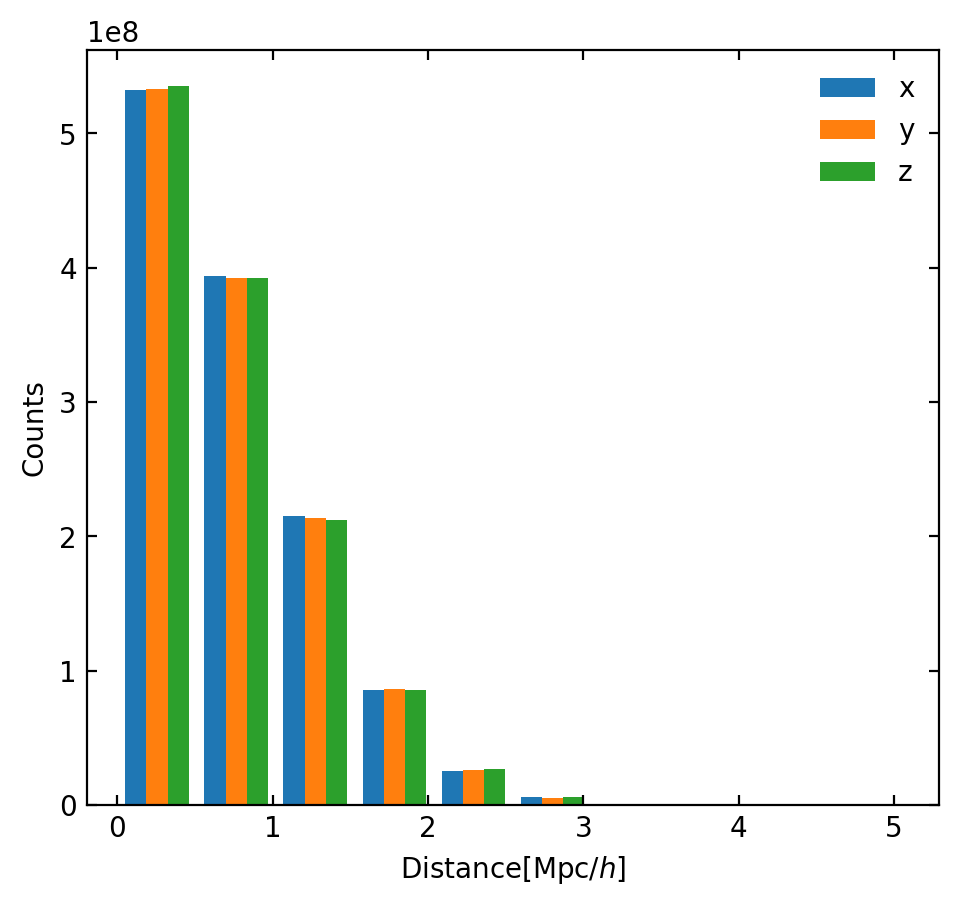

In [47]:
fig, ax = plt.subplots(dpi=200, figsize=(5.5,5))
ax.hist(np.abs(distance(q-pos,250)), bins=10, label=['x','y','z']);
ax.legend()

ax.set_ylabel('Counts')
ax.set_xlabel('Distance$[$Mpc$/h]$')

In [4]:
base = "/cosmos_storage/data_sharing/tmp_resims/1080-A/level1/haloes_10/hydro_output/snapdir_010/"
zoom = utils.read_zoom(base=base, filebase="snapshot_010")

Read data for 10546/68990 68990/21470 196484/16095 particles...
Read data for 21036/68990 68990/43827 196484/30685 particles...
Read data for 28320/68990 68990/70410 196484/44191 particles...
Read data for 37025/68990 68990/94578 196484/59238 particles...
Read data for 44012/68990 68990/120780 196484/73977 particles...
Read data for 50509/68990 68990/144069 196484/91646 particles...
Read data for 60347/68990 68990/172207 196484/101145 particles...
Read data for 68990/68990 68990/196484 196484/115467 particles...


In [18]:
with h5py.File('/cosmos_storage/data_sharing/tmp_resims/1080-A/level1/haloes_10/hydro_output/snapdir_009/snapshot_009.0.hdf5', 'r') as f:
    print(f['PartType1'].keys())

<KeysViewHDF5 ['Acceleration', 'Coordinates', 'ParticleIDs', 'Potential', 'Velocities']>


In [80]:
with h5py.File('/cosmos_storage/data_sharing/tmp_resims/1080-A/level1/haloes_10/hydro_output/snapdir_009/snapshot_009.7.hdf5', 'r') as f:
    print(f.keys())
    print(f['PartType1'].keys())

<KeysViewHDF5 ['Config', 'Header', 'Parameters', 'PartType1', 'PartType2', 'PartType3']>
<KeysViewHDF5 ['Acceleration', 'Coordinates', 'ParticleIDs', 'Potential', 'Velocities']>


In [99]:
group_len = {}
sub_moi = {}
sub_len = {}

for i in range(16):
    with h5py.File('/cosmos_storage/data_sharing/tmp_resims/1080-A/level1/haloes_4/output/groups_009/fof_subhalo_tab_009.{:d}.hdf5'.format(i), 'r') as f:
        #print(f['Subhalo'].keys())
        sub_moi[i] = f['Subhalo']['SubhaloShapeTensor'][...]
        group_len[i] = f['Group']['GroupLenType'][...]
        sub_len[i] = f['Subhalo']['SubhaloLenType'][...]

    print(np.sum(group_len[i][:,1])== np.sum(group_len[i]))
    print(np.sum(sub_len[i][:,1])== np.sum(sub_len[i]))

True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True


In [111]:
with h5py.File('/cosmos_storage/data_sharing/tmp_resims/1080-A/level4/haloes_10/hydro_output/snapdir_003/snapshot_003.{:d}.hdf5'.format(5), 'r') as f:
    print(f.keys())

<KeysViewHDF5 ['Config', 'Header', 'Parameters', 'PartType1', 'PartType2', 'PartType3']>
